In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# Load Iris dataset
iris = load_iris()
X_full = iris.data
y_actual = iris.target # Kept only for evaluation purposes later

# Apply feature scaling
scaler_kmeans = StandardScaler()
X_full_scaled = scaler_kmeans.fit_transform(X_full)
print("Dataset loaded and features scaled.")

Dataset loaded and features scaled.


In [3]:
# Take user input for number of clusters (K)
k_clusters = int(input("Enter the number of clusters (K): "))

# Train K-Means clustering model
kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
kmeans.fit(X_full_scaled)

print("\n--- Clustering Results ---")
print("Cluster Centers (Scaled):\n", kmeans.cluster_centers_)
print("\nCluster Labels for all instances:\n", kmeans.labels_)


--- Clustering Results ---
Cluster Centers (Scaled):
 [[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]

Cluster Labels for all instances:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [4]:
# Take user input for flower features
print("Enter flower features to predict its cluster:")
sl = float(input("Sepal Length: "))
sw = float(input("Sepal Width: "))
pl = float(input("Petal Length: "))
pw = float(input("Petal Width: "))

# Prepare and scale the sample
sample = np.array([[sl, sw, pl, pw]])
sample_scaled = scaler_kmeans.transform(sample)

# Predict cluster
predicted_cluster = kmeans.predict(sample_scaled)[0]
print(f"\nPredicted Cluster for the given sample: {predicted_cluster}")

Enter flower features to predict its cluster:

Predicted Cluster for the given sample: 0


Mapped Clustering Accuracy Score: 83.33%



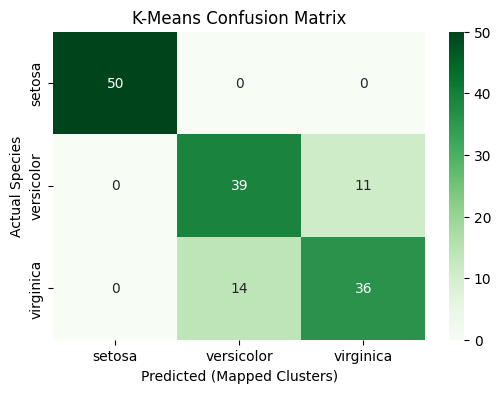

In [5]:
# To evaluate K-Means with Accuracy/CM, we map the arbitrary cluster labels 
# to the most frequent actual species label in each cluster.
mapped_labels = np.zeros_like(kmeans.labels_)

for i in range(k_clusters):
    mask = (kmeans.labels_ == i)
    if np.sum(mask) > 0:
        most_frequent_label = np.bincount(y_actual[mask]).argmax()
        mapped_labels[mask] = most_frequent_label

# Calculate evaluation metrics
km_accuracy = accuracy_score(y_actual, mapped_labels)
print(f"Mapped Clustering Accuracy Score: {km_accuracy * 100:.2f}%\n")

# Plot Confusion Matrix
km_cm = confusion_matrix(y_actual, mapped_labels)
plt.figure(figsize=(6, 4))
sns.heatmap(km_cm, annot=True, cmap="Greens", fmt="d",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted (Mapped Clusters)')
plt.ylabel('Actual Species')
plt.title('K-Means Confusion Matrix')
plt.show()

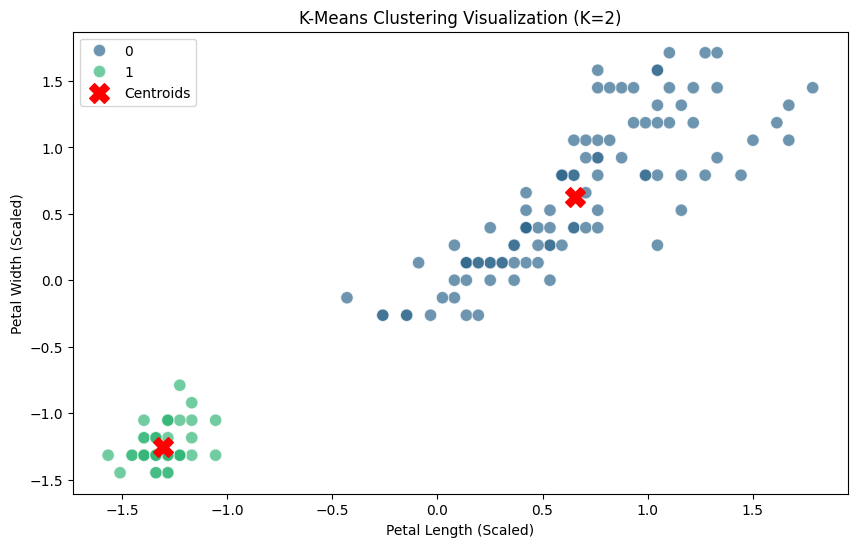


Interpretation:
The scatter plot visualizes how the algorithm groups the flowers purely based on their petal dimensions. The red 'X' markers denote the calculated center of each cluster.


In [6]:
# Extract only Petal Length (index 2) and Petal Width (index 3)
X_petal = iris.data[:, 2:4]

# Scale features
scaler_petal = StandardScaler()
X_petal_scaled = scaler_petal.fit_transform(X_petal)

# User input for K
k_visual = int(input("Enter number of clusters (K) for visualization: "))

# Apply K-Means
kmeans_vis = KMeans(n_clusters=k_visual, random_state=42, n_init=10)
kmeans_vis.fit(X_petal_scaled)

# Visualization
plt.figure(figsize=(10, 6))

# Scatter plot for data points (different color for each cluster)
sns.scatterplot(x=X_petal_scaled[:, 0], y=X_petal_scaled[:, 1], 
                hue=kmeans_vis.labels_, palette='viridis', s=80, alpha=0.7)

# Show centroids on graph
centroids = kmeans_vis.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')

plt.xlabel('Petal Length (Scaled)')
plt.ylabel('Petal Width (Scaled)')
plt.title(f'K-Means Clustering Visualization (K={k_visual})')
plt.legend()
plt.show()

print("\nInterpretation:")
print("The scatter plot visualizes how the algorithm groups the flowers purely based on their petal dimensions. The red 'X' markers denote the calculated center of each cluster.")